<h3><b>Modelling Random Forest</b><br>Classification Detection Webshell on PHP Code based on Extraction Features</h3>

In [1]:
#import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc, f1_score
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV, cross_val_score, learning_curve
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import joblib
import json


In [2]:
#import dataset
df = pd.read_csv('php_features_dataset.csv')
df.head()

,evalArgSuperglobal,dangerFuncArgSuperglobal,decodeFuncArgToSink,decodeFuncCount,maxDecodeChainDepth,dynamicFuncCallExists,dynamicIncExists,varExists,varUsageCount,assignmentCount,...,lex_symbol_count,stat_entropy,stat_length,stat_unique_char_ratio,stat_digit_ratio,stat_symbol_ratio,stat_longest_string,stat_compression_ratio,filepath,label
0,NaN,NaN,NaN,0,0,NaN,NaN,NaN,19,0,...,131,4.607249,1473,0.037339,0.001358,0.456212,23,0.310251,./Cleaned-Dataset/Normal/0001_01_01_000000_cre...,normal
1,NaN,NaN,NaN,0,0,NaN,NaN,NaN,8,0,...,64,4.656110,849,0.061249,0.000000,0.439340,13,0.368669,./Cleaned-Dataset/Normal/0001_01_01_000001_cre...,normal
2,NaN,NaN,NaN,0,0,NaN,NaN,NaN,27,0,...,159,4.555513,1812,0.029801,0.000000,0.461921,16,0.276490,./Cleaned-Dataset/Normal/0001_01_01_000002_cre...,normal
3,NaN,NaN,NaN,0,0,NaN,NaN,NaN,23,3,...,98,4.724089,2627,0.027027,0.005329,0.339931,45,0.396650,./Cleaned-Dataset/Normal/000202d76b7e71c1a3708...,normal
4,NaN,NaN,NaN,0,0,NaN,NaN,NaN,1503,552,...,6135,4.511904,95456,0.000953,0.012529,0.545372,80,0.124550,./Cleaned-Dataset/Normal/002965d250fde3bda78ea...,normal


In [3]:
df['label'].value_counts(normalize=True)

label
normal      0.532063
webshell    0.467937
Name: proportion, dtype: float64

<h2><b>Data Cleaning</b></h2>

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7875 entries, 0 to 7874
Data columns (total 48 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   evalArgSuperglobal        220 non-null    float64
 1   dangerFuncArgSuperglobal  222 non-null    float64
 2   decodeFuncArgToSink       21 non-null     float64
 3   decodeFuncCount           7875 non-null   int64  
 4   maxDecodeChainDepth       7875 non-null   int64  
 5   dynamicFuncCallExists     1077 non-null   float64
 6   dynamicIncExists          917 non-null    float64
 7   varExists                 334 non-null    float64
 8   varUsageCount             7875 non-null   int64  
 9   assignmentCount           7875 non-null   int64  
 10  classDefExists            2840 non-null   float64
 11  funcDefCount              7875 non-null   int64  
 12  superglobalAsFuncArg      7875 non-null   int64  
 13  superglobalInAsgn         7875 non-null   int64  
 14  suspiciousConcat   

<p>berdasarkan informasi diatas diketahui bahwa terdapat beberapa fitur yang didalamnya mengandung nilai null, hal ini dapa diketahui dengan jumlah nilai non-null yang tidak seragam</p>

In [5]:
df.isnull().sum()

evalArgSuperglobal          7655
dangerFuncArgSuperglobal    7653
decodeFuncArgToSink         7854
decodeFuncCount                0
maxDecodeChainDepth            0
dynamicFuncCallExists       6798
dynamicIncExists            6958
varExists                   7541
varUsageCount                  0
assignmentCount                0
classDefExists              5035
funcDefCount                   0
superglobalAsFuncArg           0
superglobalInAsgn              0
suspiciousConcat               0
ast_parse_error                0
lex_func_eval                  0
lex_func_assert                0
lex_func_system                0
lex_func_exec                  0
lex_func_shell_exec            0
lex_func_passthru              0
lex_func_popen                 0
lex_func_proc_open             0
lex_obfus_base64_decode        0
lex_obfus_gzinflate            0
lex_obfus_gzuncompress         0
lex_obfus_str_rot13            0
lex_input__GET                 0
lex_input__POST                0
lex_input_

<p>terdapat 7 fitur yang mengandung nilai null, hal ini perlu diatasi guna menciptakan model yang lebih baik</p>

In [6]:
df = df.fillna(0)
df.isnull().sum()

evalArgSuperglobal          0
dangerFuncArgSuperglobal    0
decodeFuncArgToSink         0
decodeFuncCount             0
maxDecodeChainDepth         0
dynamicFuncCallExists       0
dynamicIncExists            0
varExists                   0
varUsageCount               0
assignmentCount             0
classDefExists              0
funcDefCount                0
superglobalAsFuncArg        0
superglobalInAsgn           0
suspiciousConcat            0
ast_parse_error             0
lex_func_eval               0
lex_func_assert             0
lex_func_system             0
lex_func_exec               0
lex_func_shell_exec         0
lex_func_passthru           0
lex_func_popen              0
lex_func_proc_open          0
lex_obfus_base64_decode     0
lex_obfus_gzinflate         0
lex_obfus_gzuncompress      0
lex_obfus_str_rot13         0
lex_input__GET              0
lex_input__POST             0
lex_input__REQUEST          0
lex_input__COOKIE           0
lex_input__FILES            0
lex_includ

In [7]:
df["label"] = df["label"].map({"webshell": 1, "normal": 0})
df["label"].unique()

array([0, 1])

In [8]:
df = df.drop(columns=["filepath"])
print(df.columns)

Index(['evalArgSuperglobal', 'dangerFuncArgSuperglobal', 'decodeFuncArgToSink',
       'decodeFuncCount', 'maxDecodeChainDepth', 'dynamicFuncCallExists',
       'dynamicIncExists', 'varExists', 'varUsageCount', 'assignmentCount',
       'classDefExists', 'funcDefCount', 'superglobalAsFuncArg',
       'superglobalInAsgn', 'suspiciousConcat', 'ast_parse_error',
       'lex_func_eval', 'lex_func_assert', 'lex_func_system', 'lex_func_exec',
       'lex_func_shell_exec', 'lex_func_passthru', 'lex_func_popen',
       'lex_func_proc_open', 'lex_obfus_base64_decode', 'lex_obfus_gzinflate',
       'lex_obfus_gzuncompress', 'lex_obfus_str_rot13', 'lex_input__GET',
       'lex_input__POST', 'lex_input__REQUEST', 'lex_input__COOKIE',
       'lex_input__FILES', 'lex_include_include', 'lex_include_include_once',
       'lex_include_require', 'lex_include_require_once',
       'lex_string_literal_count', 'lex_symbol_count', 'stat_entropy',
       'stat_length', 'stat_unique_char_ratio', 'stat_digit_r

<h2><b>Exploratory Data Analysis</b></h2>

In [9]:
#dimensions of the dataset
df.shape

(7875, 47)

<p>dataset terdiri dari total 45 kolom dengan 7907 data yang tersedia</p>

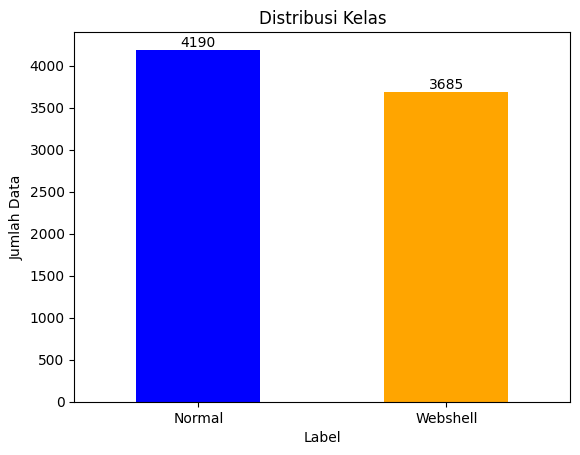

In [10]:
#visualization of class distribution
counts = df["label"].value_counts()

ax = counts.plot(kind="bar", color=["blue", "orange"])

ax.set_xticklabels(["Normal", "Webshell"], rotation=0)

for i, v in enumerate(counts):
    ax.text(i, v, str(v), ha="center", va="bottom")

plt.title("Distribusi Kelas")
plt.xlabel("Label")
plt.ylabel("Jumlah Data")
plt.show()

<p>dataset yang digunakan terdiri dari 2 label yang terbagi menjadi 4193 data berlabel normal dan 3714 data berlabel webshell</p>

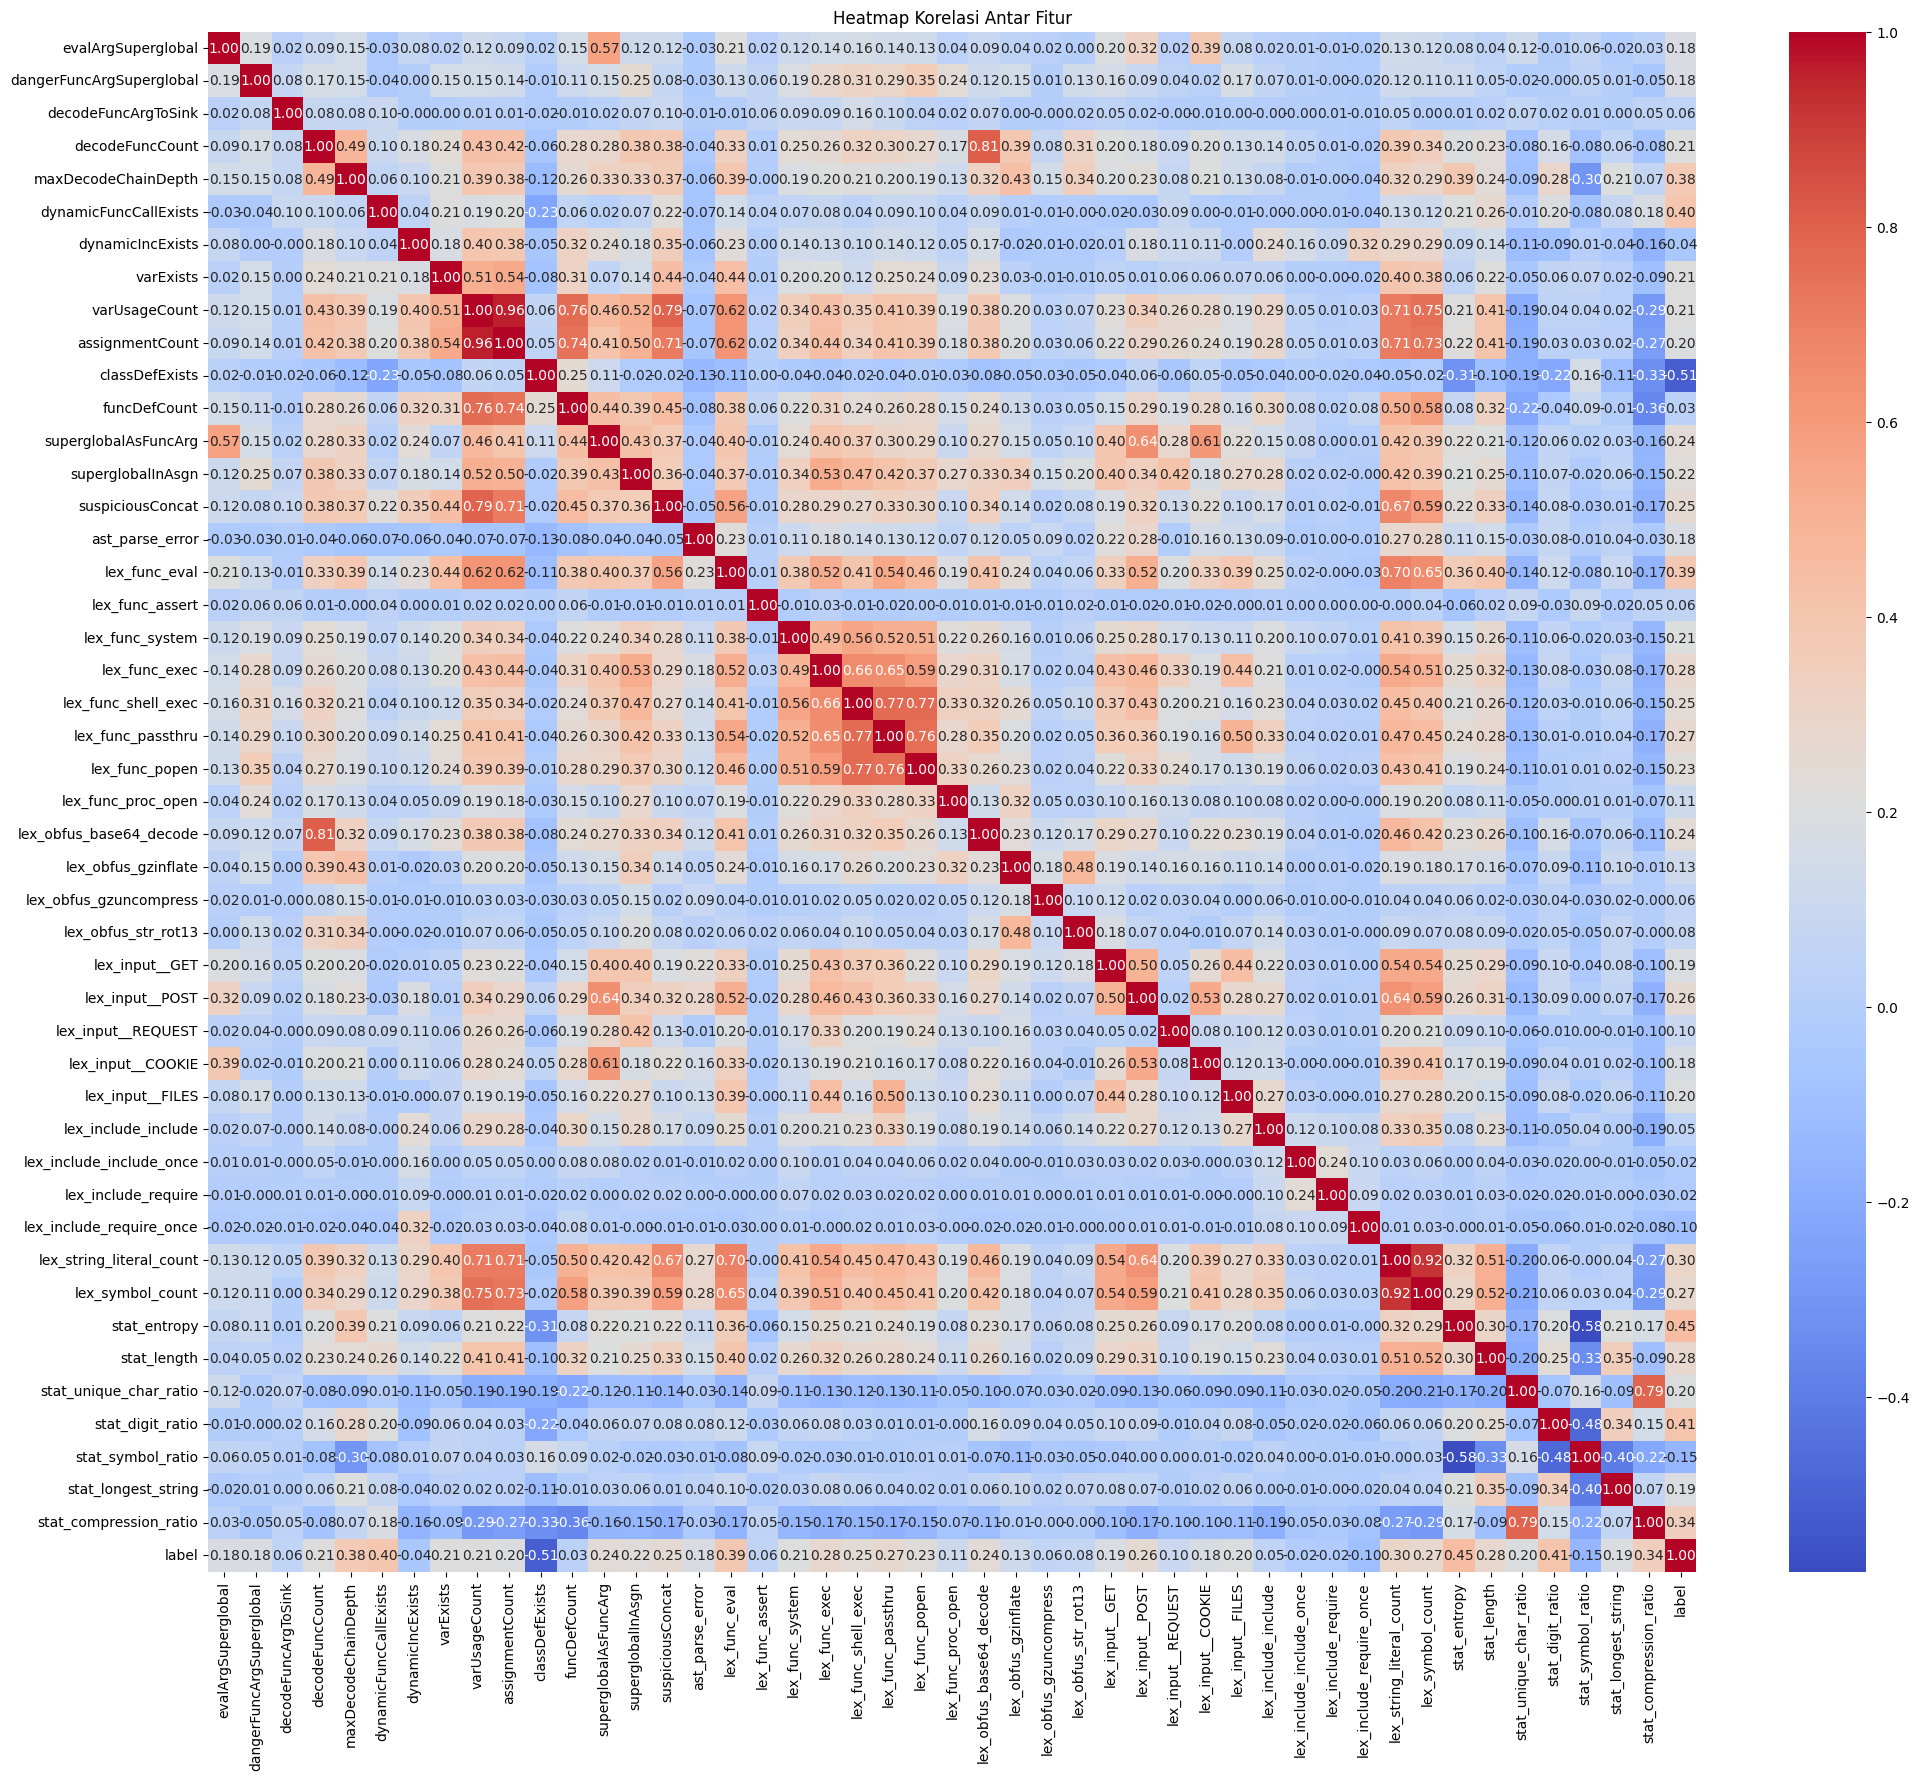

In [11]:
# Menghitung matriks korelasi
corr_matrix = df.select_dtypes(include=['float64', 'int64']).corr()

plt.figure(figsize=(24, 20))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi Antar Fitur')
plt.show()

In [12]:
#correlation with label
corr_label = df.corr()["label"].sort_values(ascending=False)
print(corr_label)

label                       1.000000
stat_entropy                0.445532
stat_digit_ratio            0.413455
dynamicFuncCallExists       0.396284
lex_func_eval               0.386204
maxDecodeChainDepth         0.375864
stat_compression_ratio      0.343393
lex_string_literal_count    0.295450
lex_func_exec               0.277248
stat_length                 0.276336
lex_symbol_count            0.269558
lex_func_passthru           0.268455
lex_input__POST             0.259276
suspiciousConcat            0.253827
lex_func_shell_exec         0.245553
lex_obfus_base64_decode     0.237114
superglobalAsFuncArg        0.235959
lex_func_popen              0.225309
superglobalInAsgn           0.224230
varUsageCount               0.212285
varExists                   0.210522
decodeFuncCount             0.210473
lex_func_system             0.208282
stat_unique_char_ratio      0.203182
assignmentCount             0.201423
lex_input__FILES            0.201197
stat_longest_string         0.193295
l

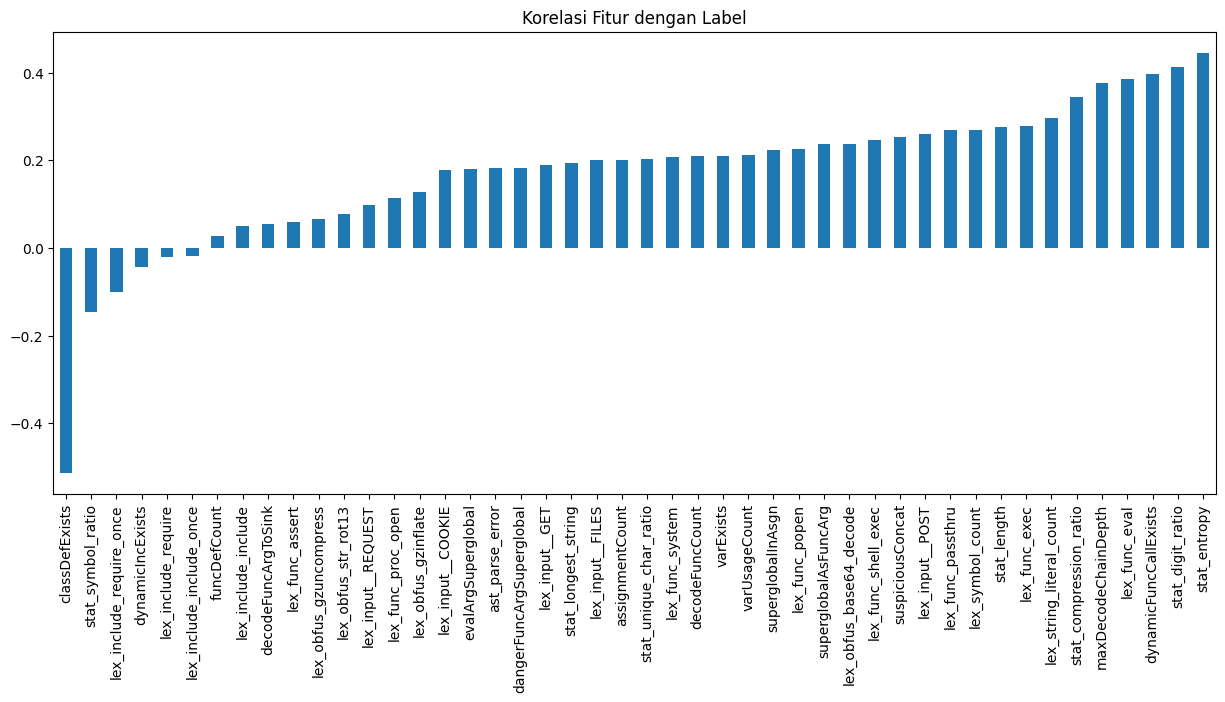

In [13]:
corr_label.drop("label").sort_values().plot(kind="bar", figsize=(15, 6))
plt.title("Korelasi Fitur dengan Label")
plt.show()

<p>nilai korelasi yang semakin mendekati 1 memiliki hubungan linear positif yang semakin kuat, sedangkan nilai korelasi yang semakin mendekati -1 memiliki hubungan linear negatif. suatu fitur x dan y yang memiliki hubungan linear negatif berarti jika nilai fitur x naik, maka nilai fitur y akan turun begitupun sebaliknya. </br> pada hubungan korelasi, fitur stat_entropy memiliki hubungan linear positif yang paling kuat diantara fitur lain terhadap label. sedangkan fitur classDefExists memiliki hubungan linear negatif paling kuat terhadap label </p>

In [14]:
features = ["stat_entropy", "stat_digit_ratio", "dynamicFuncCallExists", "lex_func_eval", "maxDecodeChainDepth", "lex_include_require", "dynamicIncExists", "lex_include_require_once", "stat_symbol_ratio", "classDefExists"]

desc = df[features].describe()
print(desc.T)

                           count      mean       std       min       25%  \
stat_entropy              7875.0  5.121634  0.510142  0.859056  4.817256   
stat_digit_ratio          7875.0  0.039304  0.072961  0.000000  0.005034   
dynamicFuncCallExists     7875.0  0.136762  0.343618  0.000000  0.000000   
lex_func_eval             7875.0  0.989714  2.709080  0.000000  0.000000   
maxDecodeChainDepth       7875.0  0.195937  0.524080  0.000000  0.000000   
lex_include_require       7875.0  0.181206  3.908407  0.000000  0.000000   
dynamicIncExists          7875.0  0.116444  0.320777  0.000000  0.000000   
lex_include_require_once  7875.0  0.206476  1.508181  0.000000  0.000000   
stat_symbol_ratio         7875.0  0.396090  0.134617  0.000216  0.358396   
classDefExists            7875.0  0.360635  0.480215  0.000000  0.000000   

                               50%       75%         max  
stat_entropy              5.098131  5.407209    7.384079  
stat_digit_ratio          0.012195  0.032799 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_18268\2610053192.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=label_name, y="stat_entropy", data=df, ax=ax[0], palette="Set2")
C:\Users\ASUS\AppData\Local\Temp\ipykernel_18268\2610053192.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=label_name, y="stat_symbol_ratio", data=df, ax=ax[1], palette="Set1")


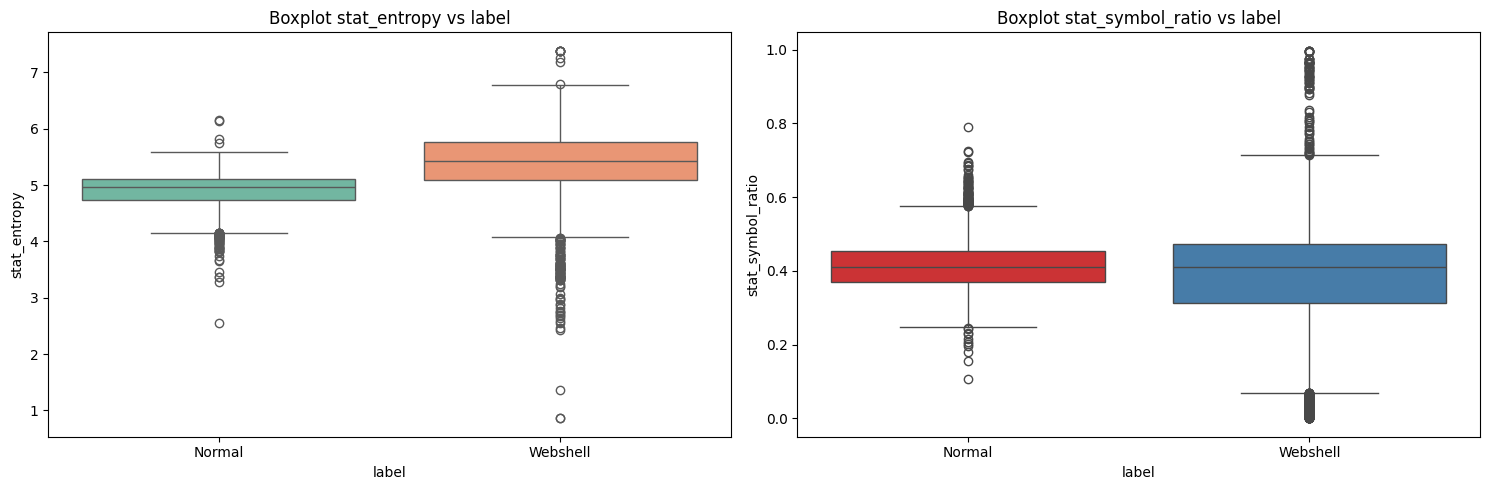

In [15]:
fig, ax = plt.subplots(1,2, figsize=(15, 5))

label_name = df["label"].map({0: "Normal", 1: "Webshell"})

sns.boxplot(x=label_name, y="stat_entropy", data=df, ax=ax[0], palette="Set2")
ax[0].set_title("Boxplot stat_entropy vs label")

sns.boxplot(x=label_name, y="stat_symbol_ratio", data=df, ax=ax[1], palette="Set1")
ax[1].set_title("Boxplot stat_symbol_ratio vs label")


plt.tight_layout()
plt.show()


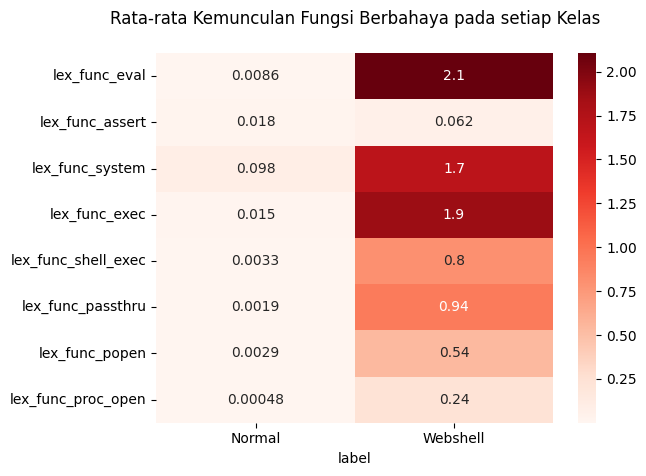

In [16]:
#visualisasi pesebaran function berbahaya tiap kelas
danger_columns = [c for c in df.columns if c.startswith("lex_func_")]
lex_mean = df.groupby("label")[danger_columns].mean().T
lex_mean = lex_mean.rename(columns={0: "Normal", 1: "Webshell"})

sns.heatmap(lex_mean.head(10), annot=True, cmap="Reds")
plt.title("Rata-rata Kemunculan Fungsi Berbahaya pada setiap Kelas\n")
plt.show()

<h3>Preprocessing Data</h3>

In [17]:
X = df.drop(columns=["label"])
y = df["label"]

Analisis Sensitivitas Model terhadap Split data:
   test_size  mean_f1_score  std_f1_score
0       0.10       0.989192      0.001893
1       0.15       0.989145      0.003420
2       0.20       0.989127      0.003408
3       0.25       0.987707      0.002593
4       0.30       0.987935      0.001927
5       0.35       0.986857      0.002605
6       0.40       0.987221      0.001230
7       0.45       0.984703      0.002094
8       0.50       0.984865      0.001438


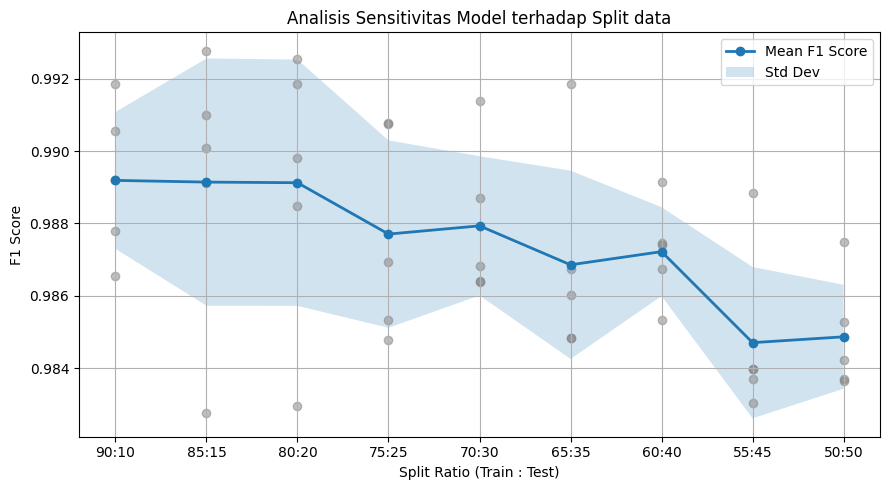

In [18]:
#tuning split ratio
test_sizes = [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
results=[]

for ts in test_sizes:
    f1_scores = []

    for seed in range(5):
        X_train, X_test, y_train, y_test = train_test_split(
            X, 
            y, 
            test_size=ts, 
            random_state=seed, 
            stratify=y
        )
        
        model = RandomForestClassifier(random_state=42)
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        f1_scores.append(f1_score(y_test, y_pred))

    results.append({
        "test_size": ts,
        "mean_f1_score": np.mean(f1_scores),
        "std_f1_score": np.std(f1_scores), 
        "all_scores": f1_scores
    })

df_results = pd.DataFrame(results)

print("Analisis Sensitivitas Model terhadap Split data:")
print(df_results[["test_size", "mean_f1_score", "std_f1_score"]])

plt.figure(figsize=(9, 5))
plt.plot(df_results["test_size"], df_results["mean_f1_score"], marker='o', linewidth=2, label="Mean F1 Score")
plt.fill_between(
    df_results["test_size"],
    df_results["mean_f1_score"] - df_results["std_f1_score"],
    df_results["mean_f1_score"] + df_results["std_f1_score"],
    alpha=0.2,
    label="Std Dev"
)
                 
for _, row in df_results.iterrows():
    x_vals = [row["test_size"]] * len(row["all_scores"])
    plt.scatter(x_vals, row["all_scores"], color='gray', alpha=0.5)

plt.title("Analisis Sensitivitas Model terhadap Split data")
plt.xlabel("Split Ratio (Train : Test)")
plt.ylabel("F1 Score")
plt.xticks(
    df_results["test_size"],
    [f"{int((1-x)*100)}:{int(x*100)}" for x in df_results["test_size"]]
    )
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((6693, 46), (1182, 46), (6693,), (1182,))

In [20]:
#hyperparameter Tuning


param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 50],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True],
    "criterion": ["gini", "entropy"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf, 
    param_distributions=param_grid, 
    n_iter=50, 
    scoring='f1', 
    n_jobs=-1, 
    cv=cv, 
    verbose=2, 
    random_state=42, 
    return_train_score=True)

random_search.fit(X_train, y_train)
results_df = pd.DataFrame(random_search.cv_results_)
results_df = results_df.sort_values(by="mean_test_score", ascending=False)
print(results_df[["params", "mean_test_score"]].head(10))


Fitting 5 folds for each of 50 candidates, totalling 250 fits
                                               params  mean_test_score
24  {'n_estimators': 200, 'min_samples_split': 2, ...         0.987694
3   {'n_estimators': 100, 'min_samples_split': 5, ...         0.987362
49  {'n_estimators': 200, 'min_samples_split': 2, ...         0.987218
16  {'n_estimators': 200, 'min_samples_split': 5, ...         0.986902
48  {'n_estimators': 100, 'min_samples_split': 5, ...         0.986888
40  {'n_estimators': 200, 'min_samples_split': 2, ...         0.986729
6   {'n_estimators': 100, 'min_samples_split': 2, ...         0.986242
37  {'n_estimators': 300, 'min_samples_split': 5, ...         0.986237
28  {'n_estimators': 200, 'min_samples_split': 10,...         0.985921
13  {'n_estimators': 200, 'min_samples_split': 2, ...         0.985914


In [21]:
results_df[["params", "mean_test_score"]].head(10).to_csv("randomSearch_results.csv", index=False)
print("Best Hyperparameters:", random_search.best_params_)
print("Best Score (F1):", random_search.best_score_)

Best Hyperparameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20, 'criterion': 'entropy', 'bootstrap': True}
Best Score (F1): 0.9876938865859648


In [22]:
results = pd.DataFrame(random_search.cv_results_)
best_model_idx = random_search.best_index_

train_score = results_df.loc[best_model_idx, "mean_train_score"]
test_score = results_df.loc[best_model_idx, "mean_test_score"]

print(f"Train Score (F1): {train_score:.4f}")
print(f"Test Score (F1): {test_score:.4f}")
print(f"Gap: {train_score - test_score:.4f}")

Train Score (F1): 0.9996
Test Score (F1): 0.9877
Gap: 0.0119


In [23]:
#model training dengan hyperparameter terbaik
best_rf = random_search.best_estimator_
best_rf.fit(X_train, y_train)
y_pred = best_rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy * 100:.2f}%')
print("\nClassification Report:\n", classification_rep)

Accuracy: 98.90%

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       632
           1       0.99      0.99      0.99       550

    accuracy                           0.99      1182
   macro avg       0.99      0.99      0.99      1182
weighted avg       0.99      0.99      0.99      1182



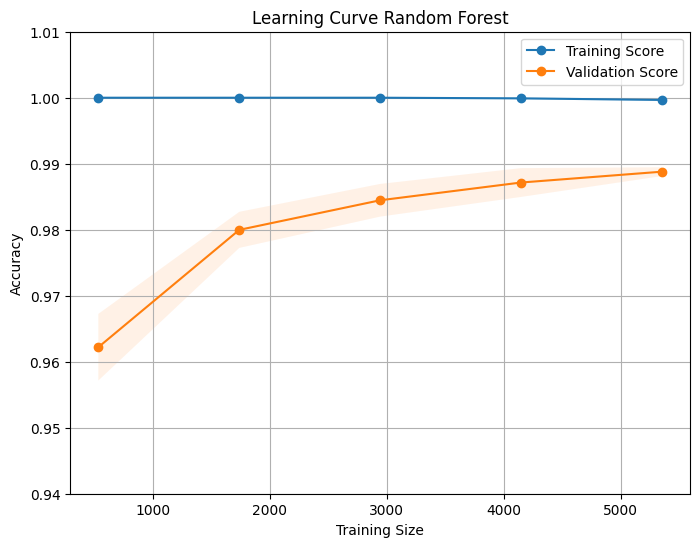

In [24]:
#learning curve dengan  parameter terbaik

train_sizes, train_scores, test_scores = learning_curve(
    best_rf,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

train_std = np.std(train_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8,6))

plt.plot(train_sizes, train_mean, label="Training Score", marker="o")
plt.plot(train_sizes, test_mean, label="Validation Score", marker="o")

plt.fill_between(train_sizes,
                 train_mean-train_std,
                 train_mean+train_std,
                 alpha=0.1)

plt.fill_between(train_sizes,
                 test_mean-test_std,
                 test_mean+test_std,
                 alpha=0.1)

plt.ylim(0.94, 1.01)

plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve Random Forest")

plt.legend()
plt.grid()

plt.show()

In [25]:
best_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=2,
    min_samples_leaf=5,
    max_features="sqrt",
    bootstrap=True,
    criterion="entropy",
    random_state=42
)
best_rf.fit(X_train, y_train)
y_pred = best_rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy * 100:.2f}%')
print("\nClassification Report:\n", classification_rep)


Accuracy: 98.14%

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.98       632
           1       0.99      0.97      0.98       550

    accuracy                           0.98      1182
   macro avg       0.98      0.98      0.98      1182
weighted avg       0.98      0.98      0.98      1182



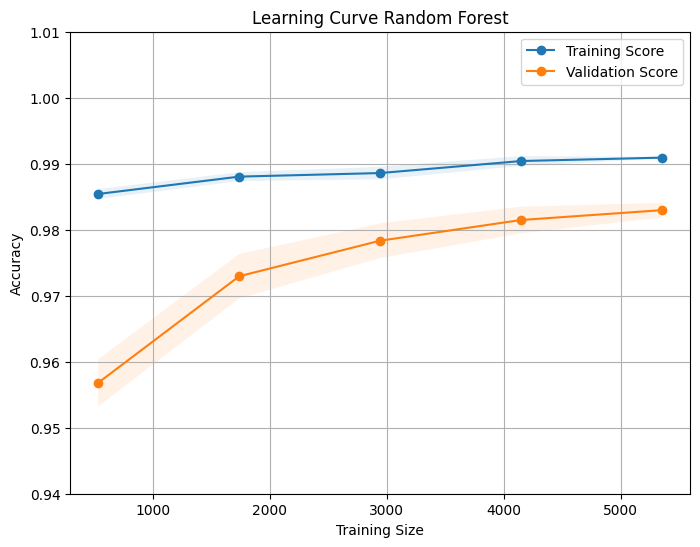

In [26]:
#learning curve dengan  parameter terbaik

train_sizes, train_scores, test_scores = learning_curve(
    best_rf,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

train_std = np.std(train_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8,6))

plt.plot(train_sizes, train_mean, label="Training Score", marker="o")
plt.plot(train_sizes, test_mean, label="Validation Score", marker="o")

plt.fill_between(train_sizes,
                 train_mean-train_std,
                 train_mean+train_std,
                 alpha=0.1)

plt.fill_between(train_sizes,
                 test_mean-test_std,
                 test_mean+test_std,
                 alpha=0.1)

plt.ylim(0.94, 1.01)

plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve Random Forest")

plt.legend()
plt.grid()

plt.show()

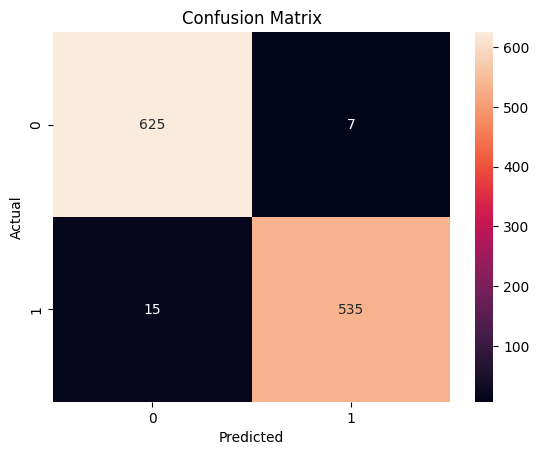

In [27]:
#confusion matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

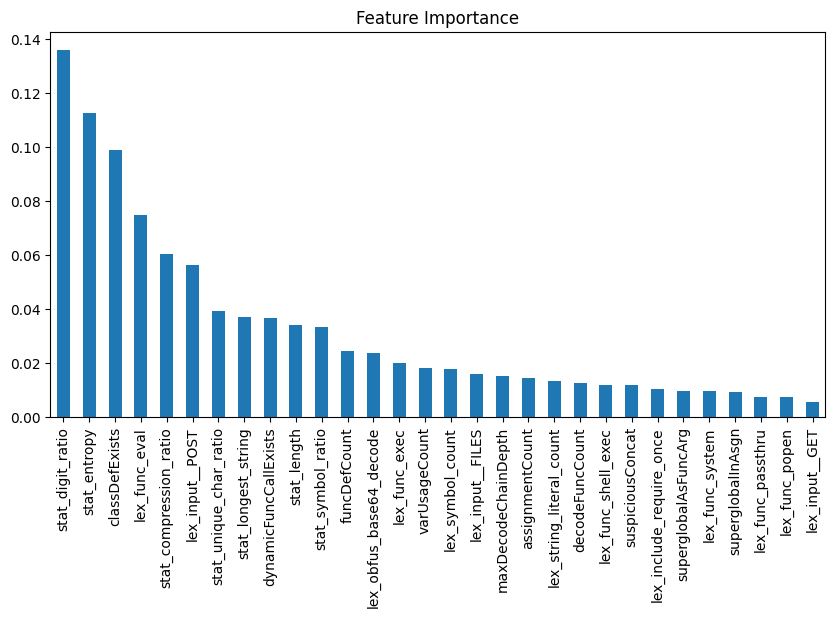

In [28]:
#feature importance 
importance = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
)

importance.sort_values(ascending=False).head(30).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Feature Importance")
plt.show()

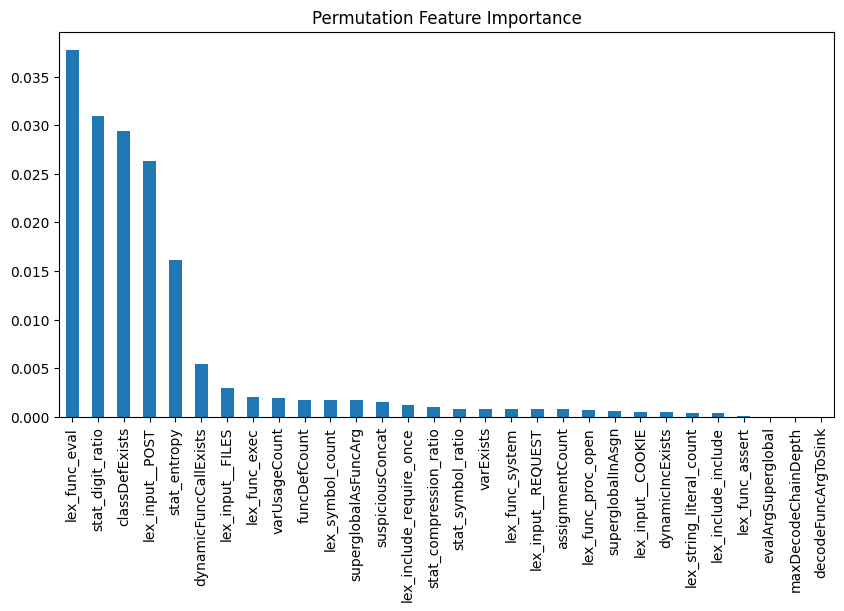

In [29]:
#permutation importance

perm_importance = permutation_importance(best_rf, X_test, y_test, n_repeats=10, random_state=42)
perm_importance_df = pd.Series(perm_importance.importances_mean, index=X_test.columns)

perm_importance_df.sort_values(ascending=False).head(30).plot(
    kind="bar",
    figsize=(10,5)
)
plt.title("Permutation Feature Importance")
plt.show()

In [30]:
permutation_sorted = perm_importance_df.sort_values(ascending=False)

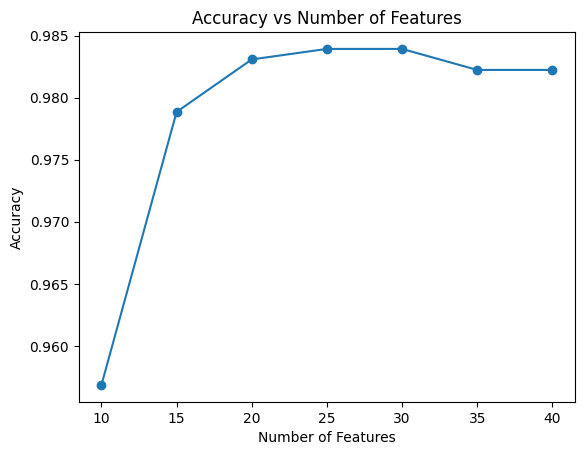

In [31]:
feature_counts = [10, 15, 20, 25, 30, 35, 40]
result = []

for count in feature_counts:
    top_features = permutation_sorted.head(count).index

    X_train_selected = X_train[top_features]
    X_test_selected = X_test[top_features]

    best_rf.fit(X_train_selected, y_train)

    y_pred_selected = best_rf.predict(X_test_selected)

    accuracy = accuracy_score(y_test, y_pred_selected)
    result.append({
        "n_features": count,
        "accuracy": accuracy,
        })


result_df = pd.DataFrame(result)
plt.plot(result_df["n_features"], result_df["accuracy"], marker="o")
plt.title("Accuracy vs Number of Features")
plt.xlabel("Number of Features")
plt.ylabel("Accuracy")
plt.xticks(feature_counts)
plt.show()


In [32]:
features_selected = permutation_sorted.head(20).index
print("Top 20 Fitur Terpenting:", features_selected)

Top 20 Fitur Terpenting: Index(['lex_func_eval', 'stat_digit_ratio', 'classDefExists',
       'lex_input__POST', 'stat_entropy', 'dynamicFuncCallExists',
       'lex_input__FILES', 'lex_func_exec', 'varUsageCount', 'funcDefCount',
       'lex_symbol_count', 'superglobalAsFuncArg', 'suspiciousConcat',
       'lex_include_require_once', 'stat_compression_ratio',
       'stat_symbol_ratio', 'varExists', 'lex_func_system',
       'lex_input__REQUEST', 'assignmentCount'],
      dtype='str')


In [ ]:
X_train_update = X_train[features_selected]
X_test_update = X_test[features_selected]

best_rf.fit(X_train_update, y_train)
y_prob = best_rf.predict_proba(X_test_update)[:, 1]
from sklearn import metrics
print('Training Accuracy : ', 
      metrics.accuracy_score(y_train,
                             best_rf.predict(X_train_update))*100)
print('Validation Accuracy : ',
      metrics.accuracy_score(y_test, 
                             best_rf.predict(X_test_update))*100)

Training Accuracy :  99.16330494546541
Validation Accuracy :  98.30795262267344


In [34]:
best_rf.fit(X_train_update, y_train)
y_pred_update = best_rf.predict(X_test_update)

accuracy = accuracy_score(y_test, y_pred_update)
classification_rep = classification_report(y_test, y_pred_update)

print(f'Accuracy: {accuracy * 100:.2f}%')
print("\nClassification Report:\n", classification_rep)

Accuracy: 98.31%

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.98       632
           1       0.99      0.98      0.98       550

    accuracy                           0.98      1182
   macro avg       0.98      0.98      0.98      1182
weighted avg       0.98      0.98      0.98      1182



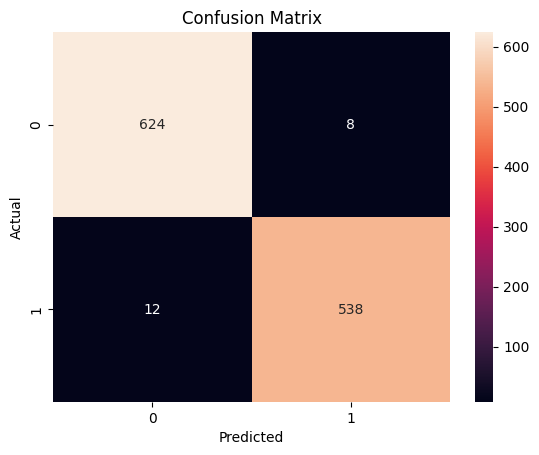

In [35]:
#confusion matrix
cm = confusion_matrix(y_test, y_pred_update)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

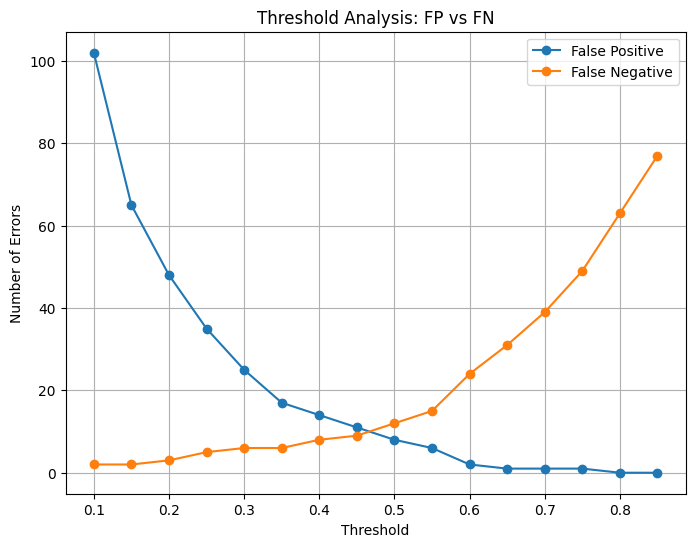

In [36]:
thresholds = np.arange(0.1, 0.9, 0.05)

fp_list = []
fn_list = []

for t in thresholds:

    y_pred = (y_prob >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    fp_list.append(fp)
    fn_list.append(fn)


plt.figure(figsize=(8,6))

plt.plot(thresholds, fp_list, label="False Positive", marker="o")
plt.plot(thresholds, fn_list, label="False Negative", marker="o")

plt.xlabel("Threshold")
plt.ylabel("Number of Errors")

plt.title("Threshold Analysis: FP vs FN")

plt.legend()
plt.grid()

plt.show()

In [37]:
for t in thresholds:
    
    y_pred = (y_prob >= t).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    print(f"Threshold {t:.2f} → FN: {fn}, FP: {fp}")

Threshold 0.10 → FN: 2, FP: 102
Threshold 0.15 → FN: 2, FP: 65
Threshold 0.20 → FN: 3, FP: 48
Threshold 0.25 → FN: 5, FP: 35
Threshold 0.30 → FN: 6, FP: 25
Threshold 0.35 → FN: 6, FP: 17
Threshold 0.40 → FN: 8, FP: 14
Threshold 0.45 → FN: 9, FP: 11
Threshold 0.50 → FN: 12, FP: 8
Threshold 0.55 → FN: 15, FP: 6
Threshold 0.60 → FN: 24, FP: 2
Threshold 0.65 → FN: 31, FP: 1
Threshold 0.70 → FN: 39, FP: 1
Threshold 0.75 → FN: 49, FP: 1
Threshold 0.80 → FN: 63, FP: 0
Threshold 0.85 → FN: 77, FP: 0


In [38]:
threshold = 0.35
y_pred_update = (y_prob >= threshold).astype(int)

accuracy = accuracy_score(y_test, y_pred_update)
classification_rep = classification_report(y_test, y_pred_update)

print(f'Accuracy: {accuracy * 100:.2f}%')
print("\nClassification Report:\n", classification_rep)


Accuracy: 98.05%

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.97      0.98       632
           1       0.97      0.99      0.98       550

    accuracy                           0.98      1182
   macro avg       0.98      0.98      0.98      1182
weighted avg       0.98      0.98      0.98      1182



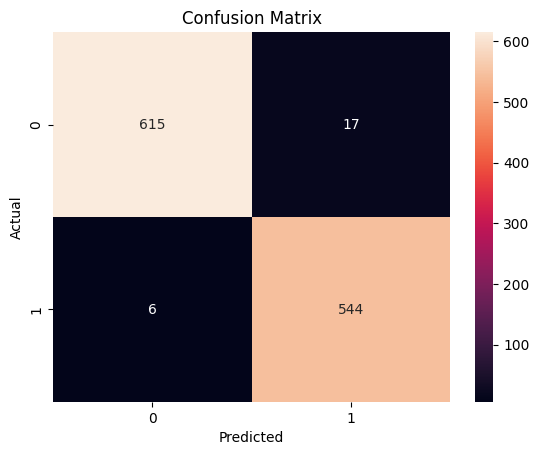

In [39]:
#confusion matrix
cm = confusion_matrix(y_test, y_pred_update)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [40]:
results = X_test_update.copy()
results["actual"] = y_test
results["predicted"] = y_pred_update

false_positive = results[(results["actual"] == 0) & (results["predicted"] == 1)]

print("Jumlah False Positive:", len(false_positive))
false_positive.to_csv("false_positive.csv", index=False)

Jumlah False Positive: 17


In [41]:
false_negative = results[(results["actual"] == 1) & (results["predicted"] == 0)]

print("Jumlah False Negative:", len(false_negative))
false_negative.to_csv("false_negative.csv", index=False)

Jumlah False Negative: 6


In [42]:
y_test.shape, y_pred_update.shape, X_test_update.shape, X_train_update.shape, y_train.shape

((1182,), (1182,), (1182, 20), (6693, 20), (6693,))

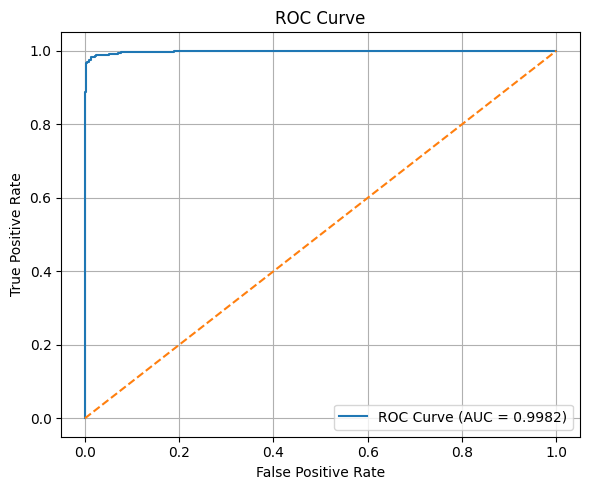

In [43]:
#kurva ROC AUC

y_prob = best_rf.predict_proba(X_test_update)[:, 1]

#ROC
fpr, tpr, threshold = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.grid(True)
plt.tight_layout()
plt.show()

In [44]:
y_train_pred = best_rf.predict(X_train_update)
train_f1 = f1_score(y_train, y_train_pred)

y_test_pred = best_rf.predict(X_test_update)
test_f1 = f1_score(y_test, y_test_pred)

print(f"Train F1 Score: {train_f1:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")
print(f"Gap: {train_f1 - test_f1:.4f}")

Train F1 Score: 0.9911
Test F1 Score: 0.9818
Gap: 0.0093


In [45]:
scores = cross_val_score(
    best_rf, 
    X_train_update,
    y_train, 
    cv=cv, 
    scoring="f1", 
    n_jobs=1
    )

print(f"Cross-Validation F1 Scores: {scores}")
print(f"Mean CV F1 Score: {scores.mean():.4f}")
print(f"Standard Deviation: {scores.std():.4f}")

Cross-Validation F1 Scores: [0.98478783 0.97666935 0.97670683 0.97506034 0.98417722]
Mean CV F1 Score: 0.9795
Standard Deviation: 0.0041


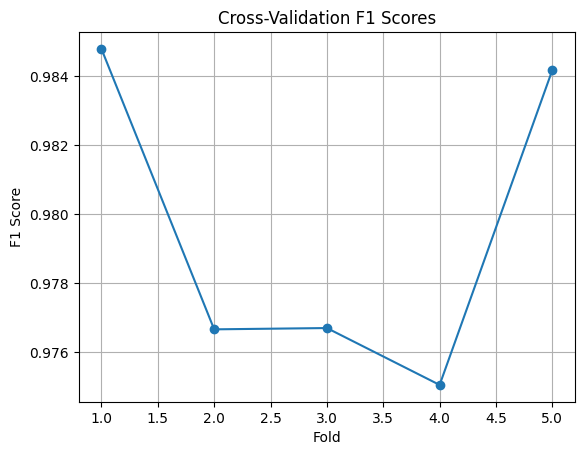

In [46]:
plt.plot(range(1, 6), scores, marker="o")
plt.title("Cross-Validation F1 Scores")
plt.xlabel("Fold")
plt.ylabel("F1 Score")
plt.grid(True)
plt.show()

In [47]:
joblib.dump(best_rf, "rf_webshell_model.joblib")

['rf_webshell_model.joblib']

In [48]:
with open('features_selected.json', 'w') as f:
    json.dump(list(features_selected), f)